In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from sklearn.linear_model import RidgeCV
import struct
from array import array
from os.path  import join

np.set_printoptions(threshold=np.inf)

In [74]:
TIME_RESOLUTION = 0.2

THRESHOLD_VOLTAGE = 0
SCALE_VOLTAGE = 11
CURVATURE = 1

IMAGE_THRESHOLD = 120

ERROR! Session/line number was not unique in database. History logging moved to new session 228


In [75]:
def create_pulse_train(basic_voltage, pulse_voltage, pulse_duration, interval_duration, pulse_quantity):
    train_length = (pulse_duration + interval_duration) * pulse_quantity

    pulse_train = np.zeros(train_length) + basic_voltage

    for i in range(pulse_quantity):
        pulse_train[i * (pulse_duration + interval_duration): (i * (pulse_duration + interval_duration)) + (pulse_duration)] = pulse_voltage
    
    return pulse_train

In [76]:
def IGT_exponent(v, threshold_voltage=THRESHOLD_VOLTAGE, scale_voltage=SCALE_VOLTAGE, curvature=CURVATURE):
    return np.exp(-((v - threshold_voltage) / scale_voltage) ** curvature)

def evolve_IGT(k, v, In_1, beta, tau):
    one_vector = np.ones_like(In_1)
    current_in_infinity = (k * (one_vector - IGT_exponent(v)))

    return current_in_infinity + (In_1 - current_in_infinity) * np.exp(-(TIME_RESOLUTION / tau) ** beta)

In [77]:
def current_to_voltage(current_in_infinity, k, threshold_voltage=THRESHOLD_VOLTAGE, scale_voltage=SCALE_VOLTAGE, curvature=CURVATURE):
    return np.power(np.log(1/(1-(current_in_infinity/k))), 1/curvature) * scale_voltage + threshold_voltage
    

In [78]:
class MnistDataloader(object):
    def __init__(self, training_images_filepath,training_labels_filepath,
                 test_images_filepath, test_labels_filepath):
        self.training_images_filepath = training_images_filepath
        self.training_labels_filepath = training_labels_filepath
        self.test_images_filepath = test_images_filepath
        self.test_labels_filepath = test_labels_filepath
    
    def read_images_labels(self, images_filepath, labels_filepath):        
        labels = []
        with open(labels_filepath, 'rb') as file:
            magic, size = struct.unpack(">II", file.read(8))
            if magic != 2049:
                raise ValueError('Magic number mismatch, expected 2049, got {}'.format(magic))
            labels = array("B", file.read())        
        
        with open(images_filepath, 'rb') as file:
            magic, size, rows, cols = struct.unpack(">IIII", file.read(16))
            if magic != 2051:
                raise ValueError('Magic number mismatch, expected 2051, got {}'.format(magic))
            image_data = array("B", file.read())        
        images = []
        for i in range(size):
            images.append([0] * rows * cols)
        for i in range(size):
            img = np.array(image_data[i * rows * cols:(i + 1) * rows * cols])
            img = img.reshape(28, 28)
            images[i][:] = img            
        
        return images, labels
            
    def load_data(self):
        x_train, y_train = self.read_images_labels(self.training_images_filepath, self.training_labels_filepath)
        x_test, y_test = self.read_images_labels(self.test_images_filepath, self.test_labels_filepath)
        return (x_train, y_train),(x_test, y_test)

In [79]:
def image_to_pulses(img, threshold=IMAGE_THRESHOLD):
    pulse_train = img.flatten()
    pulse_train = (pulse_train > threshold).astype(np.uint8)

    zeros = np.zeros(2 * len(pulse_train), dtype=np.uint8)
    zeros[::2] = pulse_train
    pulse_train = zeros

    pulse_train = pulse_train.reshape((28,28*2)).T

    return pulse_train

In [80]:
input_path = 'MNIST'
training_images_filepath = join(input_path, 'train-images-idx3-ubyte/train-images-idx3-ubyte')
training_labels_filepath = join(input_path, 'train-labels-idx1-ubyte/train-labels-idx1-ubyte')
test_images_filepath = join(input_path, 't10k-images-idx3-ubyte/t10k-images-idx3-ubyte')
test_labels_filepath = join(input_path, 't10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte')

mnist_dataloader = MnistDataloader(training_images_filepath, training_labels_filepath, test_images_filepath, test_labels_filepath)

(x_train, y_train), (x_test, y_test) = mnist_dataloader.load_data()
x_train = np.array(x_train)
y_train = np.array(y_train)
x_test = np.array(x_test)
y_test = np.array(y_test)

In [81]:
def get_images_batch(batch_size = 600, x=x_train, y=y_train):
    random_idx = np.random.choice(len(x_train), size=batch_size, replace=False)

    x_batch = x_train[random_idx]
    y_batch = np.eye(10)[y_train[random_idx]]

    return x_batch, y_batch

In [82]:
BETA = 0.56
TAU = 2.6 #ms
K = 700 #nA

BETA = 0.76
TAU = 9
K = 766

In [83]:
neuron_number = 40

# input
zeros_flush = np.zeros((28, 1))

# imagens = [{"img" : zeros_flush,
#             "label" : [1,0,0,0,0,0,0,0,0,0]}]

time_space = np.linspace(0, zeros_flush.shape[0]* TIME_RESOLUTION, zeros_flush.shape[0])

In [84]:
# Input weights
weight_input = np.random.normal(0, 1, size=(neuron_number, 28))

# Neurons' states
In = np.zeros((neuron_number, 1))

# Intern weights
weight_reservoir = np.random.normal(0, 1, size=(neuron_number, neuron_number))

# Readout weights
weight_output = np.random.normal(0, 1, size=(10, neuron_number))

true_results = []
states = []


In [85]:
images, labels = get_images_batch(12000)
true_results = []
states = []

for i, k in enumerate(images):
    image = image_to_pulses(k)

    for data in image:
        data=data.reshape(28, 1)

        sum_matrix = np.ones_like(In) @ (np.ones_like(In).T @ abs(weight_reservoir))
        sum_matrix = (lambda x: 1/x)(sum_matrix)

        result_current = (sum_matrix*weight_reservoir) @ In

        In = evolve_IGT(
            K, 
            current_to_voltage(result_current, K) + (weight_input @ data), 
            In, 
            BETA, 
            TAU
        )

    states.append(In.flatten())
    
    y = weight_output @ In

    classe = np.argmax(y)

    true_results.append(labels[i])

    for _ in range(56):
        sum_matrix = np.ones_like(In) @ (np.ones_like(In).T @ abs(weight_reservoir))
        sum_matrix = (lambda x: 1/x)(sum_matrix)

        result_current = (sum_matrix*weight_reservoir) @ In

        In = evolve_IGT(
            K, 
            current_to_voltage(result_current, K) + weight_input @ zeros_flush, 
            In, 
            BETA, 
            TAU
        )

true_results = np.array(true_results)
states = np.array(states)

ridge = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
ridge.fit(states, true_results)

weight_output= ridge.coef_
bias_output = ridge.intercept_

---------------------------------------------------------
723 // 1000 : 72.3 %


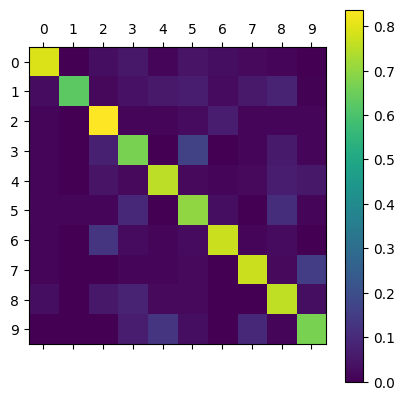

In [87]:
images_test, labels_test = get_images_batch(1000, x_test, y_test)

count_true = 0

confusion_matrix = np.zeros((10,10))

for i, k in enumerate(images_test):
    image = image_to_pulses(k)

    for data in image:
        data=data.reshape(28, 1)

        sum_matrix = np.ones_like(In) @ (np.ones_like(In).T @ abs(weight_reservoir))
        sum_matrix = (lambda x: 1/x)(sum_matrix)

        result_current = (sum_matrix*weight_reservoir) @ In

        In = evolve_IGT(
            K, 
            current_to_voltage(result_current, K) + (weight_input @ data), 
            In, 
            BETA, 
            TAU
        )
    

    y = (weight_output @ In) + bias_output.reshape(-1, 1)

    classe = np.argmax(y)
    classe_true = np.argmax(labels_test[i])

    confusion_matrix[classe][classe_true] += 1

    # print(classe, classe_true, classe == classe_true)
    count_true += classe == classe_true

    for _ in range(56):
        sum_matrix = np.ones_like(In) @ (np.ones_like(In).T @ abs(weight_reservoir))
        sum_matrix = (lambda x: 1/x)(sum_matrix)

        result_current = (sum_matrix*weight_reservoir) @ In

        In = evolve_IGT(
            K, 
            current_to_voltage(result_current, K) + weight_input @ zeros_flush, 
            In, 
            BETA, 
            TAU
        )

confusion_matrix = confusion_matrix / confusion_matrix.sum(axis=1, keepdims=True)

print("---------------------------------------------------------")
print(f"{count_true} // {len(labels_test)} : {100*(count_true/len(labels_test))} %")

plt.matshow(confusion_matrix)
plt.colorbar()
plt.xticks(np.arange(confusion_matrix.shape[0]))
plt.yticks(np.arange(confusion_matrix.shape[1]))
plt.show()